# DSM Assignment 2
Please pay attention to the following instructions:
1. Please follow carefully the steps outlined in the assignment. If you cannot solve an exercise and this hinders continuing with subsequent exercises, try to find a way to work around it and give a clear explanation for the solution you have chosen.
2. Submit your work in the form of a Jupyter notebook via Canvas, before the deadline. Your notebook should not give errors when executed with `Run All`.

# IMPORTANT: RESTRICTION ON ALLOWED LIBRARIES!!!
You are **NOT** allowed to use any scikit-learn models and functions, except `Kfold` (possibly needed in part 2) and `datasets` (needed in part 2). Material from the computer classes, including the solutions, can be used and copied freely and without penalty.

## Part 0: importing the relevant libraries

**Exercise 1:** import all the libraries you are using in this notebook.

In [ ]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import KFold

## Part 1: classification using LDA
In this part of the assignment, we will apply classification to the `moons` data generating process of scikit-learn, which is imported and visualized in the cell below.

Hint: you may use/copy material of the computer classes (including the solutions) freely and without penalty.

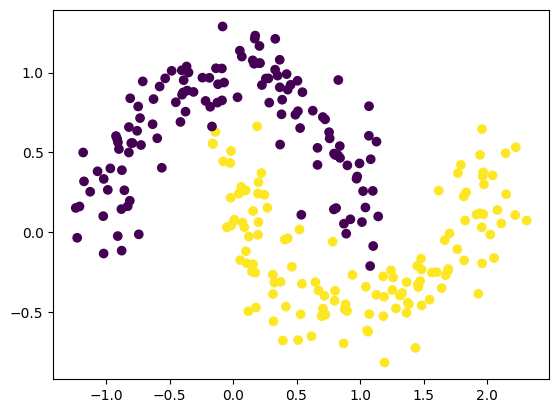

In [2]:
# DO NOT CHANGE THIS CELL!!! #
X_moons, y_moons = datasets.make_moons(n_samples = 256, noise = .15)
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons);

**Exercise 2:** use Linear Discriminant Analysis (LDA) to determine the prediction regions, based on the classification dataset given by `X_moons` and `y_moons`. Your solution should consist of two parts:
* implementation of the method.
* visualization of the prediction regions.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

In [3]:
def visualize_prediction_regions(X, y, predict, title):

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    # Prediction for each point
    Z = predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=.45, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

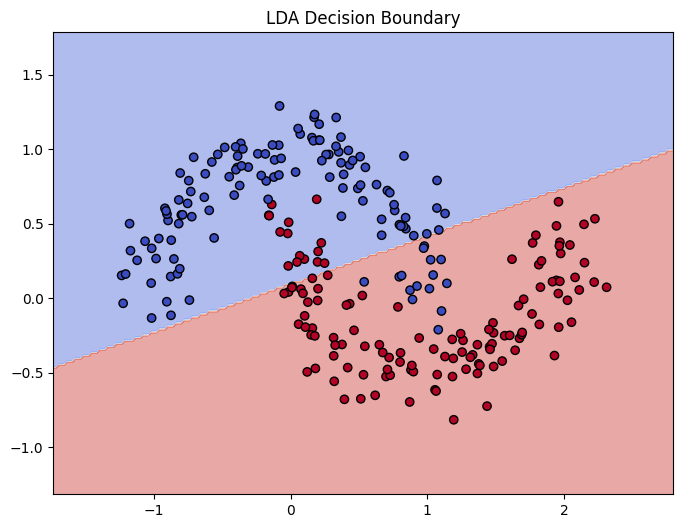

LDA Training accuracy: 0.8828


In [4]:
# Function to train LDA model
def train_LDA(X,y):
    X0 = X[y==0]
    X1 = X[y==1]

    # Calculate means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)

    #Sigma = (Sigma0*len(X0) + Sigma1*len(X1)) / (len(X0) + len(X1))
    Sigma = (Sigma0*len(X0) + Sigma1*len(X1)) / len(X1)

    n_features = X.shape[1]
    beta = np.zeros(n_features)
    beta_0 = 0

    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1)/len(X0))

    def predict(X):
        return (X.dot(beta) + beta_0 > 0).astype(int)
    return predict

# Train LDA model
LDA_predict = train_LDA(X_moons, y_moons)

visualize_prediction_regions(X_moons, y_moons, LDA_predict, "LDA Decision Boundary")

y_pred = LDA_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"LDA Training accuracy: {accuracy:.4f}")

**Exercise 3:** in the above exercise, we see that LDA performs poorly on this dataset. However, with some small adjustments one can get a much better prediction accuracy. Repeat all the steps of the previous exercise, but now for LDA with an increased feature space. Choose your derived features smartly.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

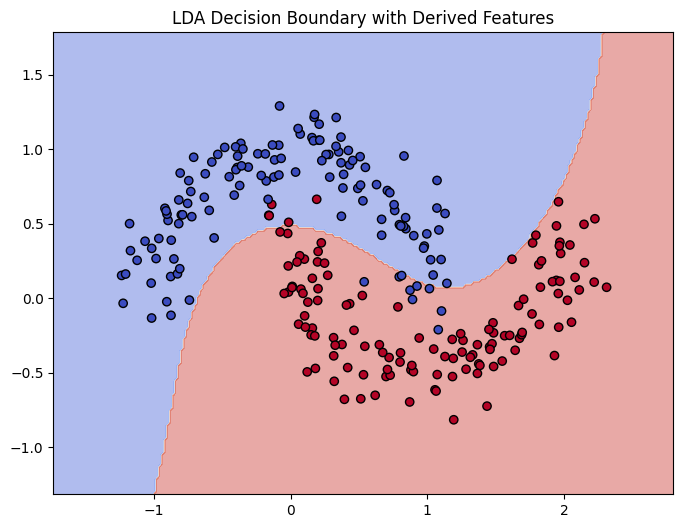

Accuracy: 0.9453


In [5]:
# Increase feature space
def add_features(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([
        X,
        x1**2, x2**2,  
        x1*x2,         
        x1**3, x2**3,  
        np.exp(-(x1**2 + x2**2)),  
        np.sin(x1), np.cos(x2) 
    ])

def train_enhanced_lda(X, y):
    # Add derived features
    X_enhanced = add_features(X)
    
    # Separate the data by class
    X0 = X_enhanced[y == 0]
    X1 = X_enhanced[y == 1]
    
    # Calculate means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)
    
    # Calculate covariance matrices
    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)
    
    # Shared covariance matrix
    Sigma = (Sigma0 * len(X0) + Sigma1 * len(X1)) / len(X_enhanced)
    
    # Add regularization
    Sigma += np.eye(Sigma.shape[0]) * 1e-2 # l2 regularization, change to find a proper result
    
    # Calculate weights and bias
    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1) / len(X0))
    
    # Define predictor function
    def predict(X):
        X_enhanced = add_features(X)
        return (X_enhanced.dot(beta) + beta_0 > 0).astype(int)
    
    return predict


# Train enhanced LDA model
enhanced_lda_predict = train_enhanced_lda(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, enhanced_lda_predict, title="LDA Decision Boundary with Derived Features")

# Calculate and print accuracy
y_pred = enhanced_lda_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")

The accuracy was enhance

## Part 2: modeling competition
This part of the assignment consists of a modeling competition. In the cell below a dataset `data_train` is loaded, consisting of 100 independent observations with 80-dimensional continuous input features `data_train.X` and a 1-dimensional continuous target variable `data_train.y`.

The goal is to use this data to train a model with the best generalization performance. The names of the students with the 3 best performing models will be announced.

This part of the assignment consists of three subsections:
* *analysis*: in this subsection you should analyze the data and try different modeling techniques and compare them in the correct way. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.
* *best model*: based on your analysis in the previous subsection, you have identified a best model. This should be defined in the code cell of this subsection, in the form of a class called `Model`.
* *generalization performance*: in this subsection the generalization performance of your best model `Model` is assessed. This is done with a test set consisting of 20000 independent datapoints that are drawn from the same distribution as the observations in `data_train`. Students do not have access to this test set.

Details of the modeling competition:
* you are only allowed to use methods that have been discussed in this course.
* the cell in the subsection *generalization performance* should **NOT** be changed!!! Not that if the test set file `data_test.pkl` is not available (which is the case for students), a file called `data_test_FAKE.pkl` is loaded instead. The data in this file has exactly the same structure as the data in `data_test.pkl`, but the actual numbers are completely random. You can use this file to test whether the cell in the subsection *generalization performance* runs without errors.

In [180]:
# DO NOT CHANGE THIS CELL!!! #
class Data():

    def __init__(self, n_samples=100, random_state=None, dgp=None):

        self.n_samples = n_samples
        self.random_state = random_state
        self.dgp = dgp
        if self.dgp is not None:
            self.X, self.y = self.dgp.generate_data(self.n_samples, self.random_state)

with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)

#### Analysis
Use the space below for your analysis of this modeling problem. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.

#### Step 1
First, we extracts the feature matrix and target vector from the training datase.

In [181]:
X, y = data_train.X, data_train.y 

In [128]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.ensemble import VotingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


Validation RMSE:  16.01373031951552


ValueError: x and y must be the same size

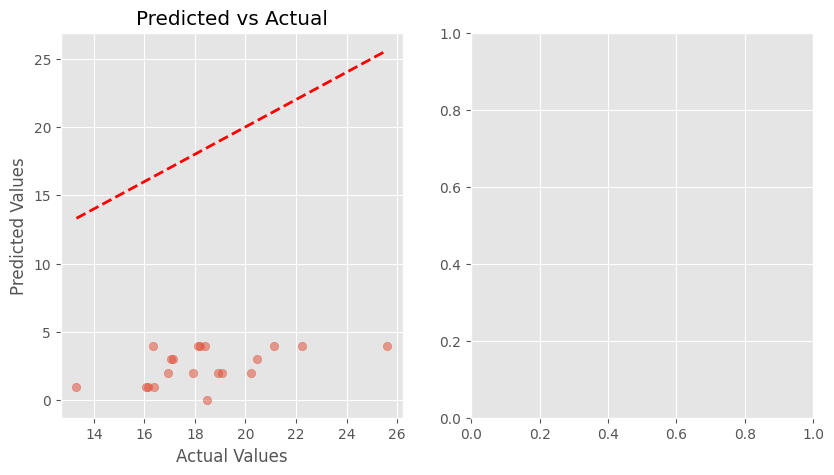

In [129]:
def train_model(X, y):
    # Feature Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Validation split
    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=36)

    # Using RandomizedSearchCV with Gaussian Mixture Model
    param_grid = {
        'n_components': [2, 3, 4, 5],
        'covariance_type': ['full', 'tied', 'diag', 'spherical'],
        'max_iter': [100, 200],
        'n_init': [1, 2]
    }

    model = GaussianMixture(random_state=36)
    random_search = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=5, cv=3, 
                                       scoring='neg_mean_squared_error', random_state=36, n_jobs=-1)
    
    # Fit the model
    random_search.fit(X_train)

    # Updating the model
    model = random_search.best_estimator_

    # Save the model and preprocessor
    joblib.dump(model, 'best_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')

    # Check performance
    y_val_pred = model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print("Validation RMSE: ", val_rmse)

    # Visualize performance
    plt.figure(figsize=(15, 5))

    # Predicted vs Actual
    plt.subplot(131)
    plt.scatter(y_val, y_val_pred, alpha=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs Actual')

    # Residual Plot
    plt.subplot(132)
    residuals = y_val - y_val_pred
    plt.scatter(y_val_pred, residuals, alpha=0.5)
    plt.hlines(y=0, xmin=y_val_pred.min(), xmax=y_val_pred.max(), colors='r', linestyles='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    # Error Distribution
    plt.subplot(133)
    sns.histplot(residuals, kde=True)
    plt.xlabel('Prediction Error')
    plt.title('Distribution of Errors')

    plt.tight_layout()
    plt.savefig('model_performance.png')

    return best_model, val_rmse

def best_model(X_new):
    model = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')
    X_new_scaled = scaler.transform(X_new)
    return model.predict(X_new_scaled)

# Train the model
train_model(X, y)

In [182]:
print("Shape of features X:", X.shape)
print("Shape of target y:", y.shape)
print("Mean of features:", np.mean(X[:, :5], axis=0))
print("Std of features:", np.std(X[:, :5], axis=0))

Shape of features X: (100, 80)
Shape of target y: (100, 1)
Mean of features: [-0.0049601   0.02298433  0.02454583  0.00929951  0.01919348]
Std of features: [0.26868377 0.13006941 0.11417552 0.14965025 0.1792746 ]


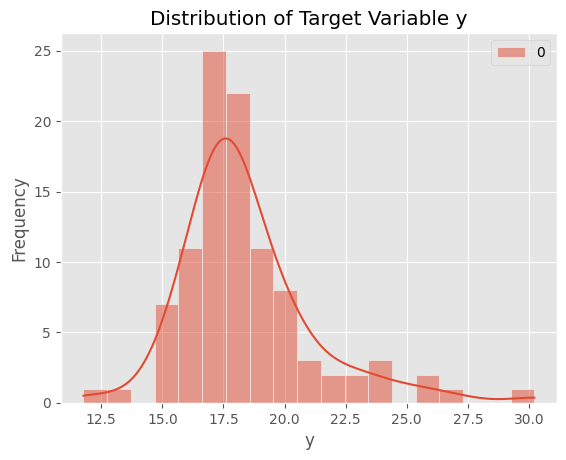

Mean of y: 18.444849817026874
Std of y: 2.7339777092552264


In [183]:
# Plot the distribution of the target variable
sns.histplot(y, kde=True, color="#6b69ea95")
plt.title('Distribution of Target Variable y')
plt.xlabel('y')
plt.ylabel('Frequency')
plt.show()
print("Mean of y:", np.mean(y))
print("Std of y:", np.std(y))


We inspect the shape and scaling of the feature maxtrix, just like the caption told us, the dataset contains 100 samples and 80 features. The features have means close to zero and standard deviations of different magnitides (0.1-0.3 for the first 5), which indicates the the data has been approximately centered but not fully standardized. This observation is important for later modelling, espically for PCA and Regression.

In [184]:
def standardize_data(data, mean=None, std=None): 
    if mean is None:
        mean = np.mean(data.X, axis=0)
    if std is None:
        std = np.std(data.X, axis=0)
        std[std == 0] = 1.0   # avoid division by zero
    
    data.X = (data.X - mean) / std
    return mean, std


mean_X, std_X = standardize_data(data_train)

X, y = data_train.X, data_train.y 

print("Shape of features X:", X.shape)
print("Shape of target y:", y.shape)
print("Mean of features:", np.mean(X[:, :5], axis=0))
print("Std of features:", np.std(X[:, :5], axis=0))

Shape of features X: (100, 80)
Shape of target y: (100, 1)
Mean of features: [ 1.11022302e-17 -3.99680289e-17 -1.36002321e-17 -1.77635684e-17
  5.21804822e-17]
Std of features: [1. 1. 1. 1. 1.]


y is continue. This is a regression problem so can not use classification method like LDA and Logistic Regression.

Number of components to explain 90% variance: 3
Number of components to explain 95% variance: 10
Number of components to explain 98% variance: 23


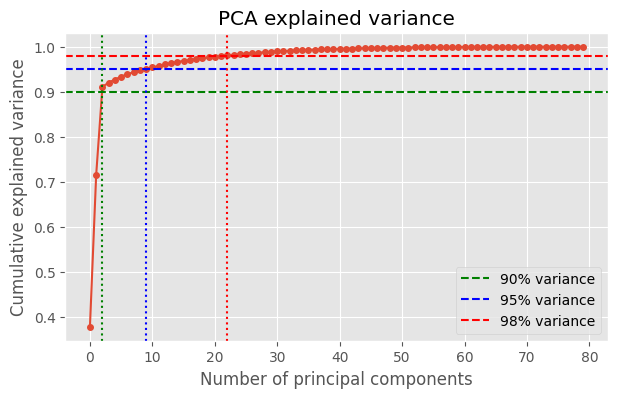

In [166]:
# Compute covariance matrix
X_centered = X - np.mean(X, axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

explained_variance = (S**2) / np.sum(S**2)
cumulative_variance = np.cumsum(explained_variance)

C90 = np.searchsorted(cumulative_variance, 0.9) + 1
C95 = np.searchsorted(cumulative_variance, 0.95) + 1
C98 = np.searchsorted(cumulative_variance, 0.98) + 1
print(f"Number of components to explain 90% variance: {C90}")
print(f"Number of components to explain 95% variance: {C95}")
print(f"Number of components to explain 98% variance: {C98}")

plt.style.use('ggplot') 
plt.figure(figsize=(7, 4))
plt.plot(cumulative_variance, marker='o', markersize=4)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.axhline(y=0.98, color='r', linestyle='--', label='98% variance')
plt.axvline(x=C90-1, color='g', linestyle=':')
plt.axvline(x=C95-1, color='b', linestyle=':')
plt.axvline(x=C98-1, color='r', linestyle=':')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.legend()
plt.grid(True)
plt.show()

The PCA analysis reveals that the dataset exhibits a strong low-dimensional structure, as the first three principal components already account for more than 95% of the total variance. This indicates that although the dataset originally has 80 features, most of the information relevant for modeling lies in just a few linear combinations of them.
Therefore, dimension reduction is highly beneficial in this setting. Using only the top components(3-10 or increase the range to 23) in a regression model should greatly reduce the risk of overfitting while retaining nearly all relevant information.

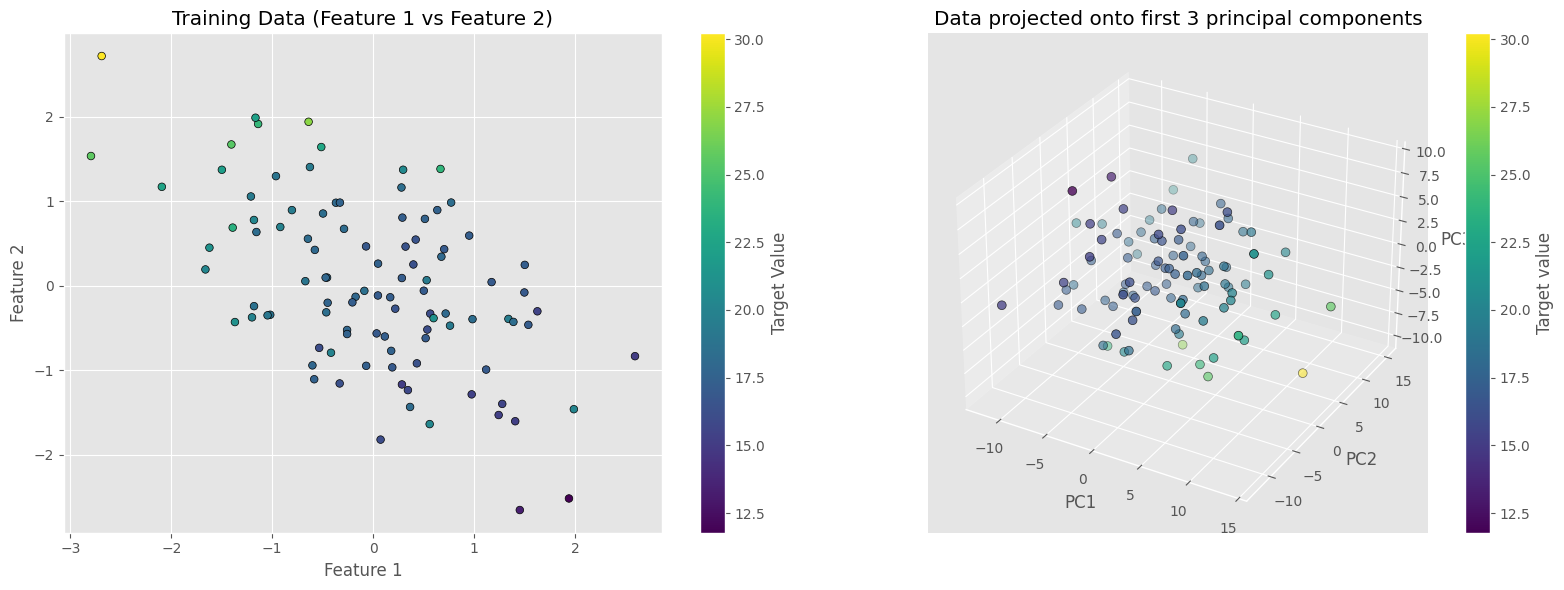

In [56]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# 2D scatter (Feature 1 vs Feature 2)
ax1 = fig.add_subplot(1, 2, 1)
sc1 = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=30)
ax1.set_title('Training Data (Feature 1 vs Feature 2)')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
plt.colorbar(sc1, ax=ax1, label='Target Value')

# 3D scatter (first 3 PCs)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
PCs3 = X_centered @ Vt.T[:, :3]
sc2 = ax2.scatter(PCs3[:, 0], PCs3[:, 1], PCs3[:, 2], c=y, cmap='viridis', edgecolor='k', s=40)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("Data projected onto first 3 principal components")
fig.colorbar(sc2, ax=ax2, label="Target value")

plt.tight_layout()
plt.show()


A 2D scatter plot using only two features (Feature 1 vs Feature 2) is insufficient because it ignores most of the 80-dimensional structure. To better captre the structure of the data, base on previous analysis, we project it into the first three principal component(PC1, PC2, PC3), which together explain about 95% of the total variance. By visualizing the dataset is concentrated along a few directions.<br>

The 3D scatter plot shows that the samples occupy a low-dimensional subspace within the original 80-dimensional feature space. Patterns, clusters, or trends related to the target variable are more visible in this PCA projection than in the 2D plot of arbitrary features. This indicates that most of the information in X can be captured using just a few principal components, which is useful for dimensionality reduction and for reducing the risk of overfitting in regression models.

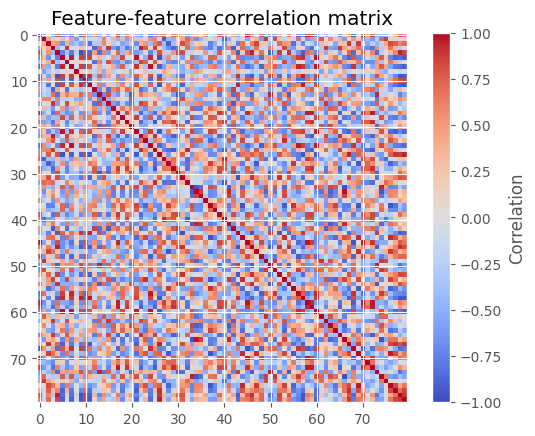

In [57]:
cov_matrix = np.corrcoef(X.T)

plt.imshow(cov_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Feature-feature correlation matrix")
plt.show()


In [85]:
plt.style.use('fast')
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["xaxis.labellocation"] = "right"
plt.rcParams["yaxis.labellocation"] = "top"
colors = ['#274E7A', '#5C8473', '#645A7E', '#24242E', '#DE4F1F']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors) 

- Note
Not a big dataset SGD will notbe a good method, not for online learning

In [188]:
def plot_for_analysis_model(y_true, y_pred, color='#274E7A'):
    """
    Generate diagnostic plots for regression models:
    1. Predicted vs Actual
    2. Residual Plot
    3. Error Distribution

    Parameters
    ----------
    y_true : array-like
        Ground truth target values.
    y_pred : array-like
        Predicted target values.
    color : str, optional
        Color for scatter/hist plots (default: '#274E7A').
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    residuals = y_true - y_pred

    plt.figure(figsize=(15, 5))

    # 1. Predicted vs Actual
    plt.subplot(131)
    plt.scatter(y_true, y_pred, alpha=0.5, color=color)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs Actual')

    # 2. Residual Plot
    plt.subplot(132)
    plt.scatter(y_pred, residuals, alpha=0.5, color=color)
    plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(),
               colors='r', linestyles='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    # 3. Error Distribution
    plt.subplot(133)
    sns.histplot(residuals, kde=True, color=color)
    plt.xlabel('Prediction Error')
    plt.title('Distribution of Errors')

    plt.tight_layout()
    plt.show()


Average MSE across 10 folds: 31.1350
Standard deviation of MSE: 24.8935


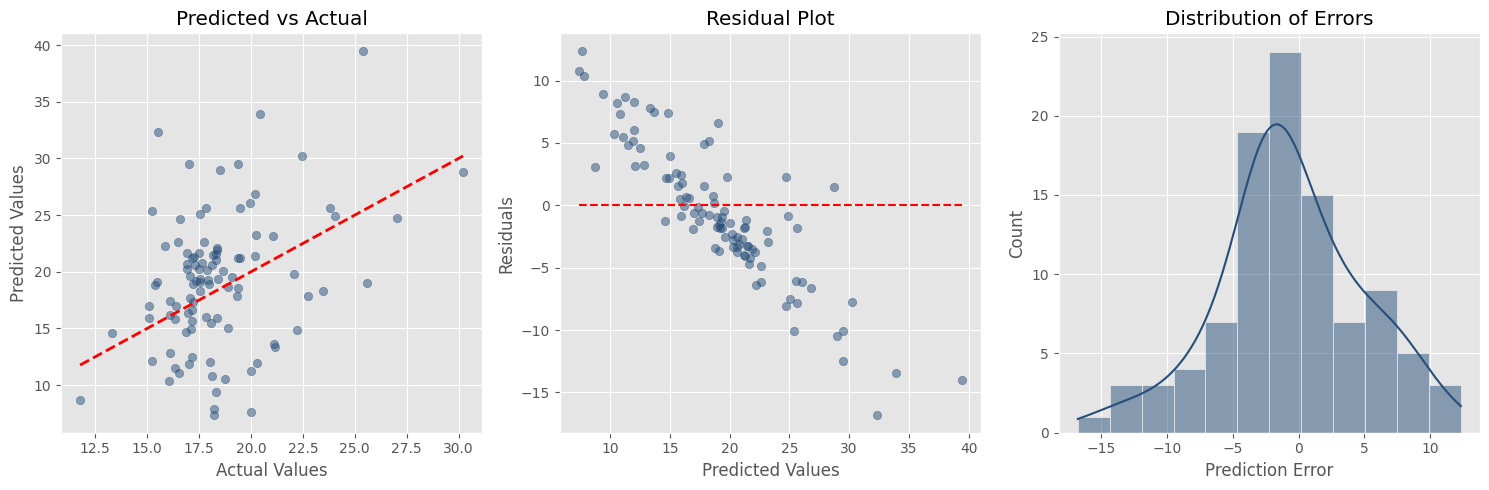

In [189]:
class ManualLinearRegression:
    def __init__(self):
        self.beta = None

    def fit(self, X, y):
        # Add a bias (intercept) term to the feature matrix
        X_b = np.c_[np.ones(X.shape[0]), X]
        
        try:
            # Use pseudo-inverse for stability
            self.beta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        except np.linalg.LinAlgError:
            print("Singular matrix error. Could not compute inverse.")
            self.beta = np.zeros(X_b.shape[1]) # Fallback
            
    def predict(self, X):
        # Add bias term for prediction
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.beta

# Wrap into a simple object like your data_train
class DataWrapper:
    def __init__(self, X, y):
        self.X = X
        self.y = y

data_train = DataWrapper(X, y)

# --- Manual K-Fold Cross-Validation Loop ---
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

# Collect predictions and actuals across folds
y_val_all = []
y_val_pred_all = []

for train_index, val_index in kfold.split(data_train.X, data_train.y):
    X_train, X_val = data_train.X[train_index], data_train.X[val_index]
    y_train, y_val = data_train.y[train_index], data_train.y[val_index]
    
    model_lr = ManualLinearRegression()
    model_lr.fit(X_train, y_train)
    
    y_pred = model_lr.predict(X_val)
    
    mse = np.mean((y_val - y_pred)**2)
    mse_scores.append(mse)
    
    # Store for visualization
    y_val_all.append(y_val)
    y_val_pred_all.append(y_pred)

# Concatenate all folds
y_val_all = np.concatenate(y_val_all)
y_val_pred_all = np.concatenate(y_val_pred_all)

# Results
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)

print(f"Average MSE across 10 folds: {mean_mse:.4f}")
print(f"Standard deviation of MSE: {std_mse:.4f}")


plot_for_analysis_model(y_val_all, y_val_pred_all, color='#274E7A')

#### Best model
Use the cell below to define your best model, in the form of a class called `Model`. The class must have (at least) the following two methods:
* `fit`: trains the model based on an instance of the class `Data` that is used as input argument.
* `predict`: predicts the target variable for observations with input features `X`, that is used as input argument.

For the sake of clarity, we have defined a placeholder version of the class `Model`. This placeholder version can be replaced by your best model class `Model`.

In [ ]:
class Model():
    """
    Placeholder Model class.
    PCA + Ridge regression with automatic ridge_lambda selection via KFold CV.
    """
    def __init__(self, **kwargs):
        self.n_components = kwargs.get('n_components', 23)
        self.ridge_values = kwargs.get('ridge_values', [0.01, 0.1, 0.5, 1.0, 10.0, 100.0])
        self.n_splits = kwargs.get('n_splits', 10)
        self.random_state = kwargs.get('random_state', 42)
        self.best_lambda = None
        self.mean_X = None
        self.std_X = None
        self.mean_y = None
        self.Vt = None
        self.coef_ = None

    def fit(self, data):
        X, y = data.X, data.y
        n, p = X.shape

        # Standardize X
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        X_scaled = (X - self.mean_X) / self.std_X

        # Center y
        self.mean_y = np.mean(y)
        y_centered = y - self.mean_y

        # PCA via SVD
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]  

        # Project onto top PCs
        Z_full = X_scaled @ self.Vt.T

        # --- KFold CV to choose best ridge_lambda ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for lam in self.ridge_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(Z_full):
                Z_train, Z_val = Z_full[train_idx], Z_full[val_idx]
                y_train, y_val = y_centered[train_idx], y_centered[val_idx]

                # Ridge regression
                beta = np.linalg.inv(Z_train.T @ Z_train + lam * np.eye(self.n_components)) @ (Z_train.T @ y_train)
                y_pred = Z_val @ beta
                rmse = np.sqrt(np.mean((y_pred - y_val) ** 2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_lambda = lam

        # --- Fit final model on full data with best lambda ---
        self.coef_ = np.linalg.inv(Z_full.T @ Z_full + self.best_lambda * np.eye(self.n_components)) @ (Z_full.T @ y_centered)

    def predict(self, X):
        # Standardize X
        X_scaled = (X - self.mean_X) / self.std_X
        Z = X_scaled @ self.Vt.T
        y_pred = Z @ self.coef_ + self.mean_y

        return y_pred.reshape(-1, 1)

In [134]:
# --- Collect validation predictions using KFold for visualization ---
X, y = data_train.X, data_train.y
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all, y_val_pred_all = [], []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Wrap fold data into a Data object
    fold_data = type("DataFold", (), {"X": X_train, "y": y_train})()

    # Train fold model
    fold_model = Model()
    fold_model.fit(fold_data)

    # Predict (flatten to 1D)
    y_val_pred = fold_model.predict(X_val).reshape(-1)
    
    # Convert lists to numpy arrays
    y_val_all = np.array(y_val_all).reshape(-1)
    y_val_pred_all = np.array(y_val_pred_all).reshape(-1)
    # Save results
    y_val_all.extend(y_val)          # y_val is already 1D
    y_val_pred_all.extend(y_val_pred) # ensure same length

# Convert lists to numpy arrays
y_val_all = np.array(y_val_all)
y_val_pred_all = np.array(y_val_pred_all)

print("Check shapes:", y_val_all.shape, y_val_pred_all.shape)  # should match


AttributeError: 'numpy.ndarray' object has no attribute 'extend'

ValueError: x and y must be the same size

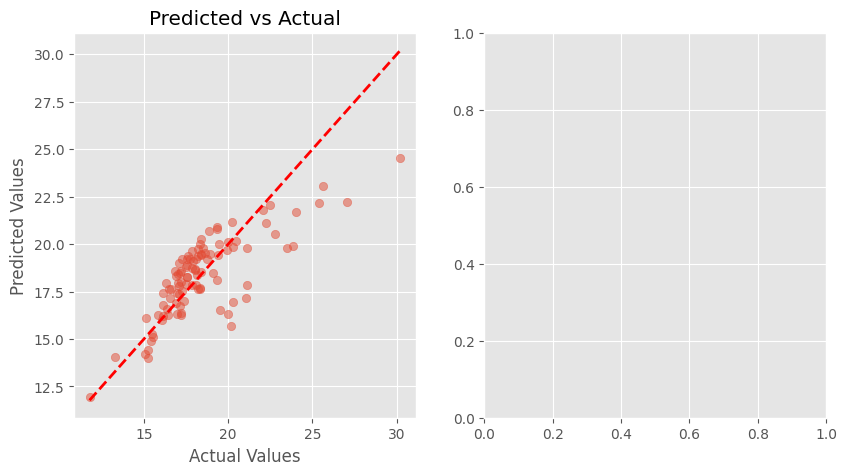

In [ ]:
model = Model()
model.fit(data_train)

# --- Collect validation predictions using KFold for visualization ---
X, y = data_train.X, data_train.y
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all, y_val_pred_all = [], []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Wrap fold data into a Data object
    fold_data = type("DataFold", (), {"X": X_train, "y": y_train})()

    # Train fold model
    fold_model = Model()
    fold_model.fit(fold_data)

    # Predict (flatten to 1D)
    y_val_pred = fold_model.predict(X_val).reshape(-1)

    # Save results
    y_val_all.extend(y_val)          # y_val is already 1D
    y_val_pred_all.extend(y_val_pred) # ensure same length

# Convert lists to numpy arrays
y_val_all = np.array(y_val_all)
y_val_pred_all = np.array(y_val_pred_all)

# --- Visualization ---
plt.figure(figsize=(15, 5))

# 1. Predicted vs Actual
plt.subplot(131)
plt.scatter(y_val_all, y_val_pred_all, alpha=0.5)
plt.plot([y_val_all.min(), y_val_all.max()],
         [y_val_all.min(), y_val_all.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual')

# 2. Residual Plot
plt.subplot(132)
residuals = y_val_all - y_val_pred_all
plt.scatter(y_val_pred_all, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_val_pred_all.min(), xmax=y_val_pred_all.max(),
           colors='r', linestyles='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# 3. Error Distribution
plt.subplot(133)
sns.histplot(residuals, kde=True)
plt.xlabel('Prediction Error')
plt.title('Distribution of Errors')

plt.tight_layout()
plt.show()


In [177]:
print("Shape of features X:", y_val_all.shape)
print("Shape of target y:",y_val_pred_all.shape)

Shape of features X: (100, 1)
Shape of target y: (100,)


In [146]:
class Model():
    """
    PCA + Elastic Net regression with automatic L1 (lambda1) and L2 (lambda2) selection via KFold CV.
    """
    def __init__(self, **kwargs):
        self.n_components = kwargs.get('n_components', 23)
        self.lambda1_values = kwargs.get('lambda1_values', [0.0, 0.01, 0.1])
        self.lambda2_values = kwargs.get('lambda2_values', [0.01, 0.1, 0.5, 1.0, 10.0, 100.0])
        self.n_splits = kwargs.get('n_splits', 5)
        self.random_state = kwargs.get('random_state', 42)
        self.lr = kwargs.get('lr', 0.01)
        self.n_epochs = kwargs.get('n_epochs', 200)
        self.best_lambda1 = None
        self.best_lambda2 = None
        self.mean_X = None
        self.std_X = None
        self.mean_y = None
        self.Vt = None
        self.coef_ = None

    def _elastic_net_sgd(self, Z, y, lam1, lam2):
        """
        Train Elastic Net using SGD.
        L1 + L2 penalty.
        """
        n, d = Z.shape
        beta = np.zeros(d)

        for epoch in range(self.n_epochs):
            idx = np.random.permutation(n)
            for i in idx:
                xi = Z[i]
                yi = y[i]
                error = yi - xi @ beta
                # L2 gradient
                grad_l2 = 2 * lam2 * beta
                # L1 gradient (subgradient)
                grad_l1 = lam1 * np.sign(beta)
                # total gradient
                grad = -2 * xi * error + grad_l2 + grad_l1
                beta -= self.lr * grad
        return beta

    def fit(self, data):
        X, y = data.X, data.y

        # --- Standardize X ---
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        X_scaled = (X - self.mean_X) / self.std_X

        # --- Center y ---
        self.mean_y = np.mean(y)
        y_centered = y - self.mean_y

        # --- PCA ---
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]
        Z_full = X_scaled @ self.Vt.T

        # --- KFold CV to select best lambda1, lambda2 ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for lam1 in self.lambda1_values:
            for lam2 in self.lambda2_values:
                rmse_list = []
                for train_idx, val_idx in kf.split(Z_full):
                    Z_train, Z_val = Z_full[train_idx], Z_full[val_idx]
                    y_train, y_val = y_centered[train_idx], y_centered[val_idx]

                    beta = self._elastic_net_sgd(Z_train, y_train, lam1, lam2)
                    y_pred = Z_val @ beta
                    rmse = np.sqrt(np.mean((y_pred - y_val) ** 2))
                    rmse_list.append(rmse)

                avg_rmse = np.mean(rmse_list)
                if avg_rmse < best_rmse:
                    best_rmse = avg_rmse
                    self.best_lambda1 = lam1
                    self.best_lambda2 = lam2

        # --- Final model on full data ---
        self.coef_ = self._elastic_net_sgd(Z_full, y_centered, self.best_lambda1, self.best_lambda2, )

    def predict(self, X):
        # Standardize and PCA projection
        X_scaled = (X - self.mean_X) / self.std_X
        Z = X_scaled @ self.Vt.T

        y_pred = Z @ self.coef_ + self.mean_y
      

        return y_pred.reshape(-1, 1)


In [121]:
import numpy as np
from sklearn.model_selection import KFold

class KNNRegressor:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # Just store training data
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        preds = []
        for x in X:
            # Compute Euclidean distances
            distances = np.linalg.norm(self.X_train - x, axis=1)
            # Get indices of k smallest distances
            nn_idx = np.argsort(distances)[:self.k]
            # Average target of neighbors
            pred = np.mean(self.y_train[nn_idx])
            preds.append(pred)
        return np.array(preds)

def cross_validate_knn(X, y, k_values, n_splits=5):
    best_k = None
    best_rmse = float("inf")

    for k in k_values:
        model = KNNRegressor(k=k)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        rmses = []
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
            rmses.append(rmse)

        avg_rmse = np.mean(rmses)
        print(f"k={k}, CV RMSE={avg_rmse:.4f}")

        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_k = k

    return best_k, best_rmse


In [147]:
# Train custom model
model = Model(n_components=23, ridge_values=[0.01, 0.1, 1.0, 10.0, 100.0], n_splits=10, random_state=42)
model.fit(data_train)

# Predict on training set (with the real y_pred, not zeros)
X_train, y_train = data_train.X, data_train.y
X_scaled = (X_train - model.mean_X) / model.std_X
Z_train = X_scaled @ model.Vt.T
y_pred_train = Z_train @ model.coef_ + model.mean_y

train_rmse = np.sqrt(np.mean((y_pred_train - y_train) ** 2))
print("Training RMSE:", train_rmse)


C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:36: RuntimeWarning: overflow encountered in multiply
  grad_l2 = 2 * lam2 * beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:41: RuntimeWarning: invalid value encountered in subtract
  beta -= self.lr * grad
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:34: RuntimeWarning: invalid value encountered in matmul
  error = yi - xi @ beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in multiply
  grad = -2 * xi * error + grad_l2 + grad_l1
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in add
  grad = -2 * xi * error + grad_l2 + grad_l1


Training RMSE: 4.508647373391665


In [ ]:
model_kwargs = {
    'n_components': 23,
    'ridge_values': [0.01, 0.1, 1.0, 10.0, 100.0],
    'n_splits': 5,
    'random_state': 42
}


#### Generalization performance
The cell below computes the generalization performance of `Model` and should **NOT** be changed.

Note that the RMSE is computed twice: once on the whole test set at once, and a second time on the individual observations one-by-one. The results should be identical.

In [148]:
### DO NOT CHANGE THIS CELL. IT WILL BE USED TO TEST YOUR CUSTOM MODEL.
### CHANGING THIS CELL WILL RESULT IN POINT DEDUCTIONS.

# Load data
with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)
try:
    with open('data/data_test.pkl', 'rb') as f:
        data_test = pickle.load(f)
except FileNotFoundError:
    with open('data/data_test_FAKE.pkl', 'rb') as f:
        data_test = pickle.load(f)

# Custom model parameters
try:
    model_kwargs
except NameError:
    model_kwargs = {}

# Train custom model
model = Model(**model_kwargs)
model.fit(data_train)

# Predict on test set
y_pred = model.predict(data_test.X)
print("RMSE (default):   ", np.sqrt(np.mean((y_pred - data_test.y)**2)))

# Predict on test set (custom implementation predicting one-by-one)
errors = []
for i in range(data_test.X.shape[0]):
    y_pred = model.predict(data_test.X[i].reshape(1, -1))
    errors.append(y_pred - data_test.y[i])
print("RMSE (one-by-one):", np.sqrt(np.mean(np.array(errors)**2)))

C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in add
  grad = -2 * xi * error + grad_l2 + grad_l1
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:41: RuntimeWarning: invalid value encountered in subtract
  beta -= self.lr * grad
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:34: RuntimeWarning: invalid value encountered in matmul
  error = yi - xi @ beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:36: RuntimeWarning: overflow encountered in multiply
  grad_l2 = 2 * lam2 * beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in multiply
  grad = -2 * xi * error + grad_l2 + grad_l1
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: invalid value encountered in add
  grad = -2 * xi * error + grad_l2 + grad_l1


RMSE (default):    28.986617146642075
RMSE (one-by-one): 28.986617146642075


In [127]:
predictions = best_model(data_test.X)
RMSE = np.sqrt(np.mean((predictions - data_test.y)**2))

print("The RMSE is: ", RMSE)

The RMSE is:  30.403433902103774


In [124]:
# Suppose you have data_train.X and data_train.y
X = data_train.X
y = data_train.y

# Try different k values
best_k, best_rmse = cross_validate_knn(X, y, k_values=[1, 3, 5, 7, 9], n_splits=5)

print(f"Best k={best_k}, with CV RMSE={best_rmse:.4f}")

# Train final model
knn = KNNRegressor(k=best_k)
knn.fit(X, y)

# Predict on test set
y_pred = knn.predict(data_test.X)
rmse_test = np.sqrt(np.mean((y_pred - data_test.y) ** 2))
print("Test RMSE:", rmse_test)


k=1, CV RMSE=3.1938
k=3, CV RMSE=3.0252
k=5, CV RMSE=2.9088
k=7, CV RMSE=2.8400
k=9, CV RMSE=2.8255
Best k=9, with CV RMSE=2.8255
Test RMSE: 28.612040085708585


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

In [ ]:
class Model():
    """
    
    """
    def __init__(self, **kwargs):
        pass

    def fit(self, data):
        pass

    def predict(self, X):
        return np.zeros(X.shape[0]).reshape(-1,1)


In [169]:
### DO NOT CHANGE THIS CELL. IT WILL BE USED TO TEST YOUR CUSTOM MODEL.
### CHANGING THIS CELL WILL RESULT IN POINT DEDUCTIONS.

# Load data
with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)
try:
    with open('data/data_test.pkl', 'rb') as f:
        data_test = pickle.load(f)
except FileNotFoundError:
    with open('data/data_test_FAKE.pkl', 'rb') as f:
        data_test = pickle.load(f)

# Custom model parameters
try:
    model_kwargs
except NameError:
    model_kwargs = {}

# Train custom model
model = Model(**model_kwargs)
model.fit(data_train)

# Predict on test set
y_pred = model.predict(data_test.X)
print("RMSE (default):   ", np.sqrt(np.mean((y_pred - data_test.y)**2)))

# Predict on test set (custom implementation predicting one-by-one)
errors = []
for i in range(data_test.X.shape[0]):
    y_pred = model.predict(data_test.X[i].reshape(1, -1))
    errors.append(y_pred - data_test.y[i])
print("RMSE (one-by-one):", np.sqrt(np.mean(np.array(errors)**2)))

C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in add
  grad = -2 * xi * error + grad_l2 + grad_l1
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:41: RuntimeWarning: invalid value encountered in subtract
  beta -= self.lr * grad
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:34: RuntimeWarning: invalid value encountered in matmul
  error = yi - xi @ beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:36: RuntimeWarning: overflow encountered in multiply
  grad_l2 = 2 * lam2 * beta
C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: invalid value encountered in add
  grad = -2 * xi * error + grad_l2 + grad_l1


RMSE (default):    28.9543270240719
RMSE (one-by-one): 28.9543270240719


C:\Users\user\AppData\Local\Temp\ipykernel_25412\1201890593.py:40: RuntimeWarning: overflow encountered in multiply
  grad = -2 * xi * error + grad_l2 + grad_l1
